# Unet

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    """(Convolution -> BatchNorm -> ReLU) * 2"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()
        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder (Upsampling + Skip Connection Fusion)
        self.up1 = DoubleConv(1024 + 512, 512)
        self.up2 = DoubleConv(512 + 256, 256)
        self.up3 = DoubleConv(256 + 128, 128)
        self.up4 = DoubleConv(128 + 64, 64)

        # Final Pixel Classifier
        self.outc = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder Pass & Save Skip Outputs
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        # Bottleneck
        b = self.bottleneck(x4)

        # Decoder Pass with Dynamic F.interpolate Matching
        # Up 1
        b_up = F.interpolate(b, size=x4.shape[2:], mode="bilinear", align_corners=False)
        x = self.up1(torch.cat([x4, b_up], dim=1))

        # Up 2
        x_up = F.interpolate(x, size=x3.shape[2:], mode="bilinear", align_corners=False)
        x = self.up2(torch.cat([x3, x_up], dim=1))

        # Up 3
        x_up = F.interpolate(x, size=x2.shape[2:], mode="bilinear", align_corners=False)
        x = self.up3(torch.cat([x2, x_up], dim=1))

        # Up 4
        x_up = F.interpolate(x, size=x1.shape[2:], mode="bilinear", align_corners=False)
        x = self.up4(torch.cat([x1, x_up], dim=1))

        return self.outc(x)


# DeepLab

In [2]:
class AtrousConvBlock(nn.Module):
    """Conv with custom dilation rate to expand the receptive field without downsampling"""

    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling Module"""

    def __init__(self, in_channels, out_channels=256):
        super().__init__()

        # 1x1 standard convolution
        self.aspp1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        # Parallel Atrous blocks with different dilation footprints
        self.aspp2 = AtrousConvBlock(in_channels, out_channels, dilation=6)
        self.aspp3 = AtrousConvBlock(in_channels, out_channels, dilation=12)
        self.aspp4 = AtrousConvBlock(in_channels, out_channels, dilation=18)

        # Image-level global context pooling block
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        # Projection layer after concatenating all parallel views
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        size = x.shape[2:]

        # Extract features across all paths
        feat1 = self.aspp1(x)
        feat2 = self.aspp2(x)
        feat3 = self.aspp3(x)
        feat4 = self.aspp4(x)

        # Process global context path and interpolate back to feature map size
        feat5 = self.global_pool(x)
        feat5 = F.interpolate(feat5, size=size, mode="bilinear", align_corners=False)

        # Concatenate along channel axis and project
        out = torch.cat([feat1, feat2, feat3, feat4, feat5], dim=1)
        return self.project(out)


class DeepLabStyle(nn.Module):
    def __init__(self, in_channels=3, num_classes=1):
        super().__init__()

        # Initial standard downsampling stages
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Mid-level spatial feature extractor stage
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        # High-level feature representation stage before ASPP context layer
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        # ASPP module
        self.aspp = ASPP(in_channels=512, out_channels=256)

        # Final segmentation prediction layer
        self.classifier = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[2:]

        # Forward pass extraction
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Context extraction via Atrous spatial pyramid pooling
        x = self.aspp(x)

        # Direct class projection
        x = self.classifier(x)

        # Direct final upscale back to original input dimensions
        return F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)


In [3]:
if __name__ == "__main__":
    # Create mock batch: Batch=2, Channels=3, Height=256, Width=256
    mock_batch = torch.randn(2, 3, 256, 256)

    unet = UNet(in_channels=3, num_classes=1)
    deeplab = DeepLabStyle(in_channels=3, num_classes=1)

    unet_out = unet(mock_batch)
    deeplab_out = deeplab(mock_batch)

    print(f"Input Shape:       {mock_batch.shape}")
    print(
        f"U-Net Output:      {unet_out.shape}"
    )  # Expected: torch.Size([2, 1, 256, 256])
    print(
        f"DeepLab Output:    {deeplab_out.shape}"
    )  # Expected: torch.Size([2, 1, 256, 256])


Input Shape:       torch.Size([2, 3, 256, 256])
U-Net Output:      torch.Size([2, 1, 256, 256])
DeepLab Output:    torch.Size([2, 1, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.804341..4.718859].


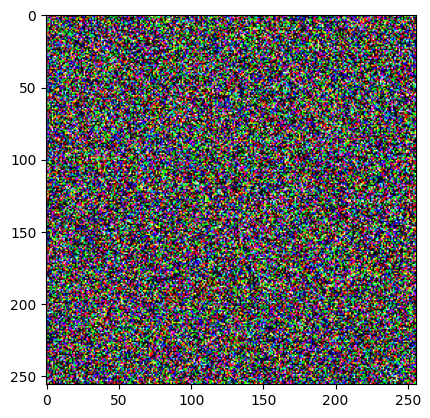

In [7]:
import matplotlib.pyplot as plt

plt.imshow(mock_batch[0].permute(1, 2, 0).detach().numpy())
plt.show()


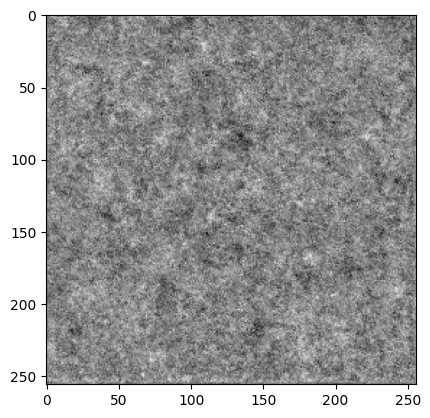

In [4]:
import matplotlib.pyplot as plt

plt.imshow(unet_out[0, 0].detach().numpy(), cmap="gray")
plt.show()

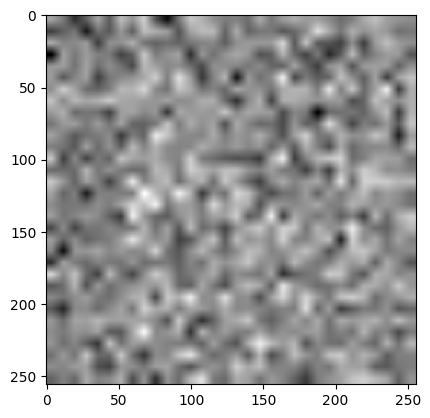

In [6]:
import matplotlib.pyplot as plt

plt.imshow(deeplab_out[0, 0].detach().numpy(), cmap="gray")
plt.show()
